In [2]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df = pd.read_csv('student_data.csv')
print("Shape:", df.shape)
df.head()

Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 395 entries, 0 to 394
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   school      395 non-null    object
 1   sex         395 non-null    object
 2   age         395 non-null    int64 
 3   address     395 non-null    object
 4   famsize     395 non-null    object
 5   Pstatus     395 non-null    object
 6   Medu        395 non-null    int64 
 7   Fedu        395 non-null    int64 
 8   Mjob        395 non-null    object
 9   Fjob        395 non-null    object
 10  reason      395 non-null    object
 11  guardian    395 non-null    object
 12  traveltime  395 non-null    int64 
 13  studytime   395 non-null    int64 
 14  failures    395 non-null    int64 
 15  schoolsup   395 non-null    object
 16  famsup      395 non-null    object
 17  paid        395 non-null    object
 18  activities  395 non-null    object
 19  nursery     395 non-null    object
 20  higher    

In [4]:
print(df.isnull().sum().sum(), "total missing values")
print(df.duplicated().sum(), "duplicate rows")

0 total missing values
0 duplicate rows


In [5]:
key_cols = ['G1', 'G2', 'G3', 'studytime', 'absences', 'age']
df[key_cols].describe()

,G1,G2,G3,studytime,absences,age
count,395.000000,395.000000,395.000000,395.000000,395.000000,395.000000
mean,10.908861,10.713924,10.415190,2.035443,5.708861,16.696203
std,3.319195,3.761505,4.581443,0.839240,8.003096,1.276043
min,3.000000,0.000000,0.000000,1.000000,0.000000,15.000000
25%,8.000000,9.000000,8.000000,1.000000,0.000000,16.000000
50%,11.000000,11.000000,11.000000,2.000000,4.000000,17.000000
75%,13.000000,13.000000,14.000000,2.000000,8.000000,18.000000
max,19.000000,19.000000,20.000000,4.000000,75.000000,22.000000


In [7]:
g3 = df['G3']
print("Mean:", round(g3.mean(), 2))
print("Median:", g3.median())
print("Mode:", g3.mode()[0])
print("Standard Deviation:", round(g3.std(), 2))
print("Variance:", round(g3.var(), 2))
print("Range:", g3.max() - g3.min())

Mean: 10.42
Median: 11.0
Mode: 10
Standard Deviation: 4.58
Variance: 20.99
Range: 20


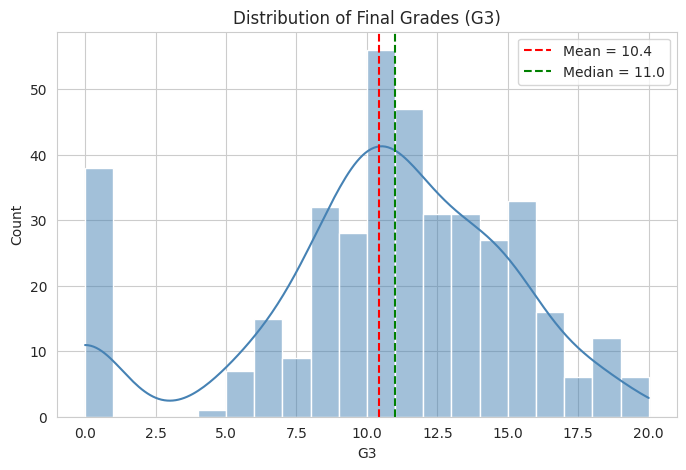

In [8]:
plt.figure(figsize=(8,5))
sns.histplot(df['G3'], bins=20, kde=True, color='steelblue')
plt.axvline(g3.mean(), color='red', linestyle='--', label=f'Mean = {g3.mean():.1f}')
plt.axvline(g3.median(), color='green', linestyle='--', label=f'Median = {g3.median():.1f}')
plt.title('Distribution of Final Grades (G3)')
plt.legend()
plt.show()

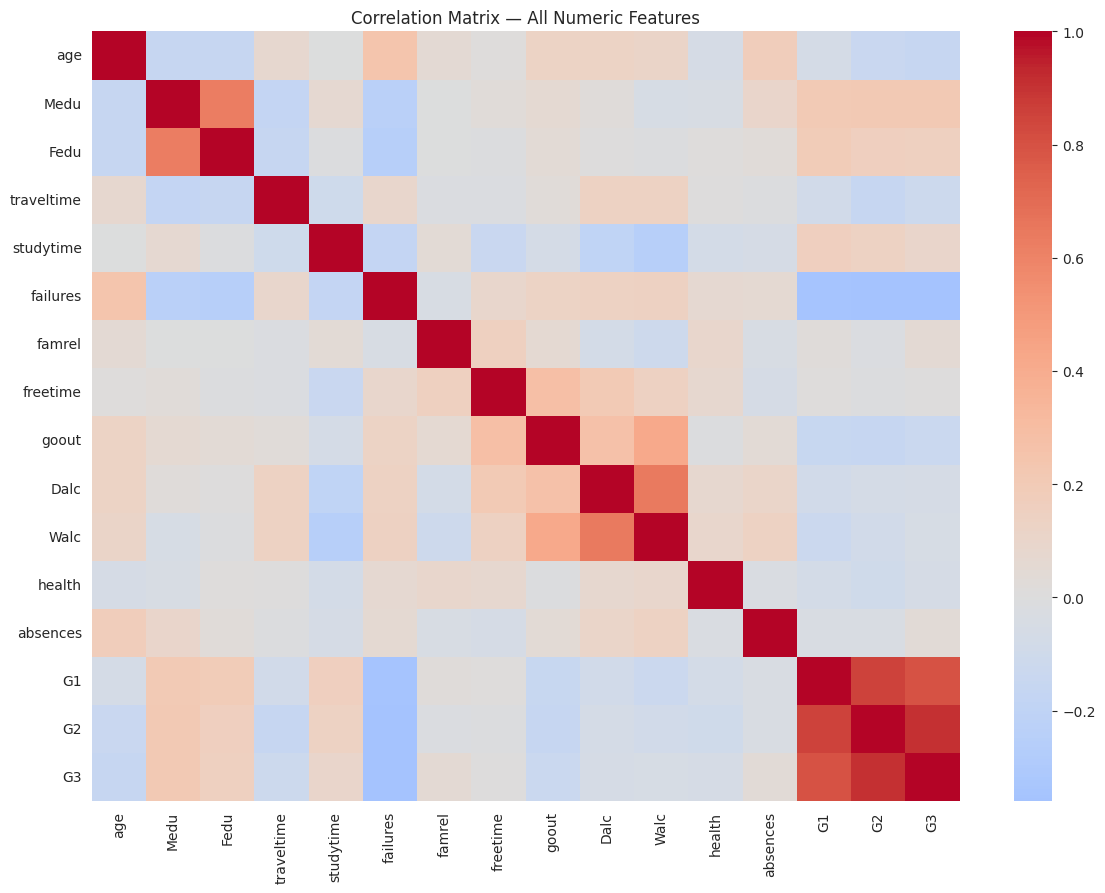

In [9]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(14,10))
sns.heatmap(corr, annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Matrix — All Numeric Features')
plt.show()

In [10]:
print(df[['G3','G1','G2','studytime','absences','Dalc','Medu']].corr()['G3'].sort_values(ascending=False))

G3           1.000000
G2           0.904868
G1           0.801468
Medu         0.217147
studytime    0.097820
absences     0.034247
Dalc        -0.054660
Name: G3, dtype: float64


In [11]:
male_grades = df[df['sex'] == 'M']['G3']
female_grades = df[df['sex'] == 'F']['G3']

t_stat, p_value = stats.ttest_ind(male_grades, female_grades)
print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

if p_value < 0.05:
    print("Result: Statistically significant difference between male and female grades (p < 0.05)")
else:
    print("Result: No statistically significant difference (p >= 0.05)")

T-statistic: 2.062
P-value: 0.0399
Result: Statistically significant difference between male and female grades (p < 0.05)


/tmp/ipykernel_3012/2804112601.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sex', y='G3', palette='Set2')


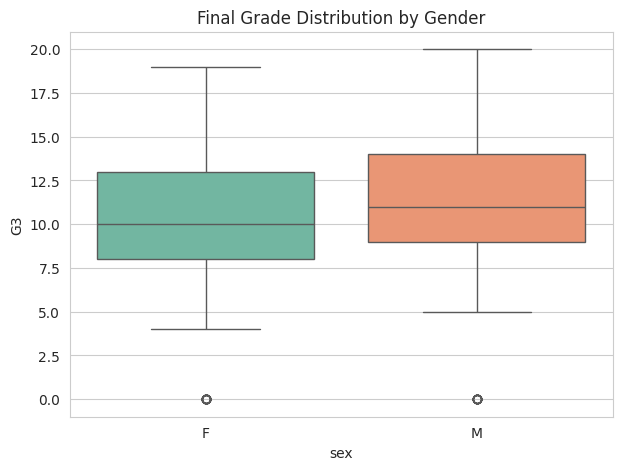

In [12]:
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x='sex', y='G3', palette='Set2')
plt.title('Final Grade Distribution by Gender')
plt.show()

In [13]:
groups = [group['G3'].values for name, group in df.groupby('Mjob')]
f_stat, p_val = stats.f_oneway(*groups)
print(f"F-statistic: {f_stat:.3f}, P-value: {p_val:.4f}")

F-statistic: 3.754, P-value: 0.0052


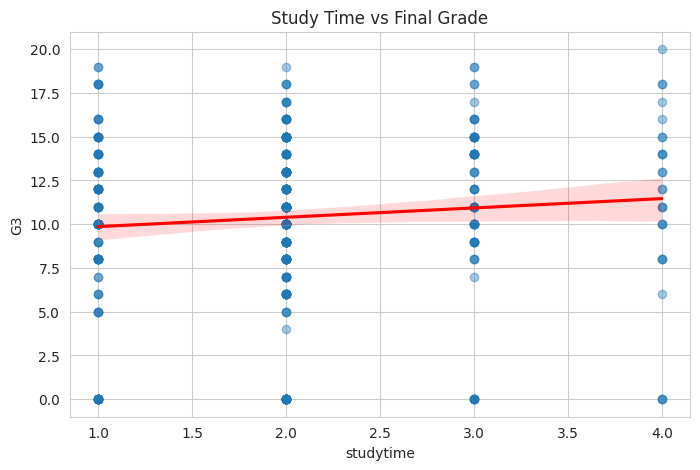

In [14]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='studytime', y='G3', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('Study Time vs Final Grade')
plt.show()

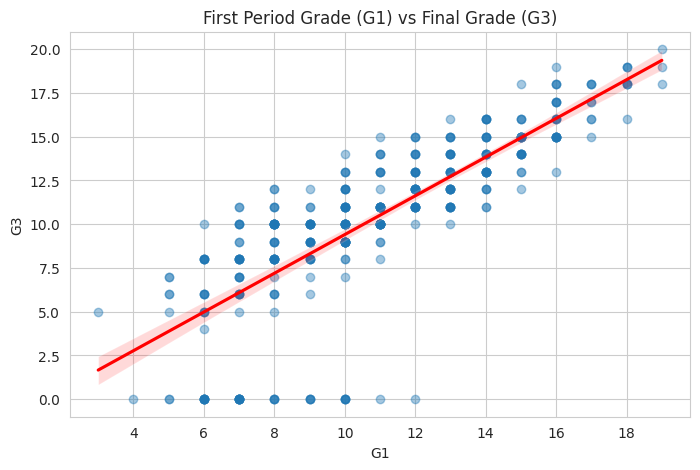

In [15]:
plt.figure(figsize=(8,5))
sns.regplot(data=df, x='G1', y='G3', scatter_kws={'alpha':0.4}, line_kws={'color':'red'})
plt.title('First Period Grade (G1) vs Final Grade (G3)')
plt.show()